# 🌿 Model 1 — Target EC & Saran Rasio A/B Mix (Cloud)

**Input :** `n, p, k, ec_aktual, kelembapan_udara, kelembapan_tanah, suhu, fase, usia_hst`  
**Output :** `target_ec` → dari situ diturunkan `volume_a_ml` dan `volume_b_ml` per 10 L air

### Logika A/B Mix
| | Mix A | Mix B |
|---|---|---|
| **Isi utama** | Ca(NO₃)₂, KNO₃, Fe-EDTA | KH₂PO₄, K₂SO₄, MgSO₄ |
| **Fungsi** | Sumber N & Ca | Sumber P, K, Mg |

Rasio disesuaikan fase:
- **Vegetatif** → A sedikit lebih banyak (N dominan)
- **Generatif** → B sedikit lebih banyak (K & P dominan)

> **Dataset:** `dataset_paprika_adaptif.csv` — 5000 sampel sintetis paprika (*Capsicum annuum* L.)  
> Kolom: `n, p, k, ec_aktual, kelembapan_udara, kelembapan_tanah, suhu, fase, usia_hst, target_ec, vpd`

## Cell 1 — Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('✅ Library siap')

✅ Library siap


## Cell 2 — Generate / Load Dataset

### Referensi Parameter Dataset
| Parameter | Referensi | Keterangan |
|-----------|-----------|------------|
| EC vegetatif 1.4–1.8 dS/m | Ding et al. (2022), *Plants* | EC optimal fase vegetatif paprika |
| EC generatif 1.8–2.4 dS/m | Kim et al. (2023), *Horticulturae* | EC fase generatif & berbuah |
| Formula VPD (Magnus-Tetens) | Allen et al. (1998), FAO-56 | `es = 0.6108 × exp(17.27T/(T+237.3))` |
| N 120–250 ppm, K 150–300 ppm | Savvas & Gruda (2018); Haifa Group | Kisaran makronutrien paprika hidroponik |
| Usia HST paprika | Kumari et al. (2021), *Hort. Sci.* | Vegetatif 7–60 HST; generatif >40 HST |

In [14]:
df = pd.read_csv('dataset/dataset_paprika_adaptif.csv')
display(df.describe().round(3))
print(f'\nFase: Vegetatif={int((df.fase==0).sum())} | Generatif={int((df.fase==1).sum())}')

,n,p,k,ec_aktual,kelembapan_udara,kelembapan_tanah,suhu,fase,usia_hst,target_ec,vpd
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,185.113,58.121,216.084,1.779,82.931,57.533,27.372,0.450,58.132,1.751,0.637
std,37.569,10.020,44.611,0.231,5.399,15.911,2.308,0.498,42.005,0.185,0.248
min,120.000,40.000,150.010,1.205,63.110,30.010,20.000,0.000,7.000,1.220,0.118
25%,152.468,50.860,177.088,1.589,79.278,43.752,25.780,0.000,24.000,1.610,0.465
50%,186.510,57.650,204.675,1.745,82.885,57.475,27.315,0.000,41.000,1.720,0.616
75%,217.510,64.262,256.122,1.984,86.610,71.382,28.900,1.000,92.000,1.870,0.791
max,249.970,79.970,299.990,2.406,95.000,84.980,35.000,1.000,149.000,2.330,1.767



Fase: Vegetatif=2748 | Generatif=2252


## Cell 3 — Fitur Engineering & Split Data

| Fitur | Satuan | Keterangan |
|-------|--------|------------|
| `n, p, k` | ppm | Makronutrien dari sensor/analisis larutan |
| `ec_aktual` | mS/cm | EC larutan nutrisi terukur |
| `kelembapan_udara` | % | Relatif humidity — input VPD |
| `kelembapan_tanah` | % | Kelembapan substrat/media tanam |
| `suhu` | °C | Suhu udara — input VPD |
| `fase` | 0/1 | 0=vegetatif, 1=generatif |
| `usia_hst` | hari | Hari Setelah Tanam |
| `vpd` *(derived)* | kPa | Vapor Pressure Deficit dari suhu & RH |
| `rasio_nk` *(derived)* | — | N:K ratio sebagai indikator dominasi nutrisi |

In [15]:
# Hitung VPD jika belum ada
if 'vpd' not in df.columns:
    es = 0.6108 * np.exp((17.27 * df['suhu']) / (df['suhu'] + 237.3))
    df['vpd'] = (es - es * (df['kelembapan_udara'] / 100)).round(4)
    print('  VPD dihitung dari suhu & kelembapan_udara')

# Rasio N:K — indikator dominasi vegetatif vs generatif
df['rasio_nk'] = (df['n'] / df['k']).round(4)

# Fitur input (sesuai kolom dataset_paprika_adaptif.csv)
FEATURES = [
    'n', 'p', 'k',
    'ec_aktual',
    'kelembapan_udara', 'kelembapan_tanah',
    'suhu',
    'fase', 'usia_hst',
    'vpd', 'rasio_nk'
]
TARGET = 'target_ec'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Fitur  : {FEATURES}')
print(f'Train  : {X_train.shape} | Test: {X_test.shape}')
print(f'Target : {y.min():.3f} – {y.max():.3f} mS/cm')

Fitur  : ['n', 'p', 'k', 'ec_aktual', 'kelembapan_udara', 'kelembapan_tanah', 'suhu', 'fase', 'usia_hst', 'vpd', 'rasio_nk']
Train  : (4000, 11) | Test: (1000, 11)
Target : 1.220 – 2.330 mS/cm


## Cell 4 — Train Random Forest Regressor

In [16]:
# Random Forest Regressor (Breiman, 2001)
# Aplikasi di nutrisi hidroponik: Al-Shalabi et al. (2024, Sci. Rep.)
rf = RandomForestRegressor(
    n_estimators     = 200,
    max_depth        = 12,
    min_samples_leaf = 3,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(rf, X, y, cv=5, scoring='r2')

print('=== Evaluasi Model ===')
print(f'MAE           : {mae:.4f} mS/cm')
print(f'RMSE          : {rmse:.4f} mS/cm')
print(f'R²            : {r2:.4f}')
print(f'CV R² (5-fold): {cv.mean():.4f} ± {cv.std():.4f}')

=== Evaluasi Model ===
MAE           : 0.0436 mS/cm
RMSE          : 0.0555 mS/cm
R²            : 0.9138
CV R² (5-fold): 0.9150 ± 0.0046


## Cell 5 — Visualisasi Evaluasi

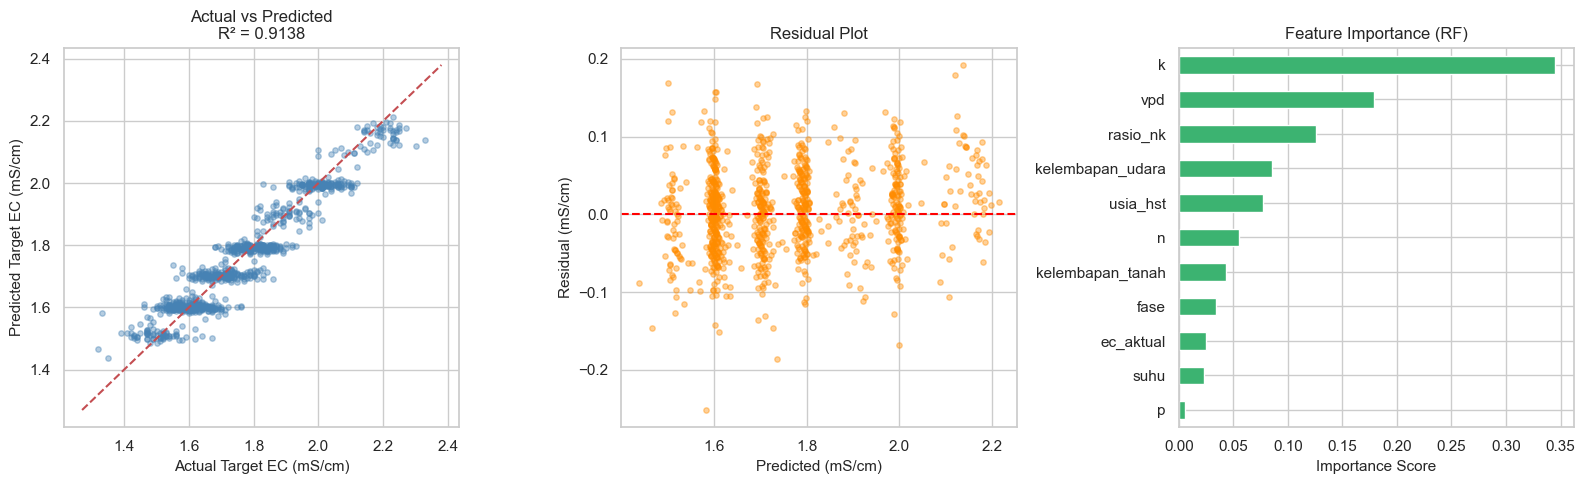

📊 Grafik disimpan -> eval_model1_rf.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lim = [y_test.min()-0.05, y_test.max()+0.05]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Target EC (mS/cm)', fontsize=11)
axes[0].set_ylabel('Predicted Target EC (mS/cm)', fontsize=11)
axes[0].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12)

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted (mS/cm)', fontsize=11)
axes[1].set_ylabel('Residual (mS/cm)', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12)

fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Feature Importance (RF)', fontsize=12)
axes[2].set_xlabel('Importance Score', fontsize=11)

plt.tight_layout()
plt.savefig('eval_model1_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Grafik disimpan -> eval_model1_rf.png')

## Cell 6 — Fungsi Hitung Saran Rasio A/B Mix

**Asumsi konsentrat:** 1 mS/cm EC ≈ 5 ml A + 5 ml B per 10 L air  
**Rasio fase (Kim et al., 2023; standar PBG Netherlands):**
- Vegetatif → A:B = 55:45 (N & Ca dominan via Ca(NO₃)₂, KNO₃)
- Generatif → A:B = 45:55 (K & P dominan via KH₂PO₄, K₂SO₄)

In [8]:
def saran_ab_mix(target_ec, fase, rasio_nk, volume_air_liter=10):
    """
    Hitung volume A & B mix (ml) untuk volume_air_liter liter air.

    Logika:
    - total_ml = target_ec * 5 * (vol_air / 10)
    - Vegetatif : split A = 0.55 (N dominan)
    - Generatif : split A = 0.45 (K/P dominan)
    - N:K > 1.3 : tambah porsi A (N sudah tinggi di tanaman)
    - N:K < 0.7 : kurangi porsi A (K sudah tinggi di tanaman)
    """
    total_ml = target_ec * 5 * (volume_air_liter / 10)
    split_a  = 0.55 if fase == 0 else 0.45

    if rasio_nk > 1.3:
        split_a = min(split_a + 0.05, 0.70)
    elif rasio_nk < 0.7:
        split_a = max(split_a - 0.05, 0.30)

    return {
        'target_ec'   : round(target_ec, 2),
        'volume_air_L': volume_air_liter,
        'volume_a_ml' : round(total_ml * split_a, 1),
        'volume_b_ml' : round(total_ml * (1 - split_a), 1),
        'rasio_a_b'   : f'{round(split_a*100)}:{round((1-split_a)*100)}',
        'catatan'     : 'Tuang A dulu, aduk, baru tuang B'
    }


def prediksi_full(n, p, k, ec_aktual,
                  kelembapan_udara, kelembapan_tanah,
                  suhu, fase, usia_hst,
                  volume_air_liter=10):
    """
    Endpoint utama: input sensor -> prediksi target_ec + saran A/B mix.

    Parameter:
        n, p, k          : konsentrasi makronutrien (ppm)
        ec_aktual        : EC larutan saat ini (mS/cm)
        kelembapan_udara : RH udara (%)
        kelembapan_tanah : kelembapan substrat (%)
        suhu             : suhu udara (C)
        fase             : 0=vegetatif, 1=generatif
        usia_hst         : hari setelah tanam
        volume_air_liter : volume air yang akan dicampur (L)
    """
    # Magnus-Tetens VPD (Allen et al., 1998)
    es    = 0.6108 * np.exp((17.27 * suhu) / (suhu + 237.3))
    vpd   = float(es - es * (kelembapan_udara / 100))
    rasio = n / k if k > 0 else 1.0

    x_input = np.array([[n, p, k, ec_aktual,
                          kelembapan_udara, kelembapan_tanah,
                          suhu, fase, usia_hst,
                          vpd, rasio]])

    pred_ec = float(rf.predict(x_input)[0])
    pred_ec = round(np.clip(pred_ec, 1.2, 2.35), 2)

    saran = saran_ab_mix(pred_ec, fase, rasio, volume_air_liter)
    saran['vpd_kpa']  = round(vpd, 3)
    saran['usia_hst'] = int(usia_hst)
    return saran


print('=== Contoh Prediksi: Vegetatif (HST 30) ===')
hasil = prediksi_full(
    n=195, p=52, k=185,
    ec_aktual=1.55,
    kelembapan_udara=82, kelembapan_tanah=60,
    suhu=27, fase=0, usia_hst=30
)
for kk, v in hasil.items(): print(f'  {kk:<18}: {v}')

print()
print('=== Contoh Prediksi: Generatif (HST 90) ===')
hasil2 = prediksi_full(
    n=145, p=65, k=255,
    ec_aktual=1.90,
    kelembapan_udara=75, kelembapan_tanah=55,
    suhu=29, fase=1, usia_hst=90
)
for kk, v in hasil2.items(): print(f'  {kk:<18}: {v}')

=== Contoh Prediksi: Vegetatif (HST 30) ===
  target_ec         : 1.6
  volume_air_L      : 10
  volume_a_ml       : 4.4
  volume_b_ml       : 3.6
  rasio_a_b         : 55:45
  catatan           : Tuang A dulu, aduk, baru tuang B
  vpd_kpa           : 0.642
  usia_hst          : 30

=== Contoh Prediksi: Generatif (HST 90) ===
  target_ec         : 1.99
  volume_air_L      : 10
  volume_a_ml       : 4.0
  volume_b_ml       : 6.0
  rasio_a_b         : 40:60
  catatan           : Tuang A dulu, aduk, baru tuang B
  vpd_kpa           : 1.001
  usia_hst          : 90


## Cell 7 — Visualisasi Saran A/B Mix per Fase

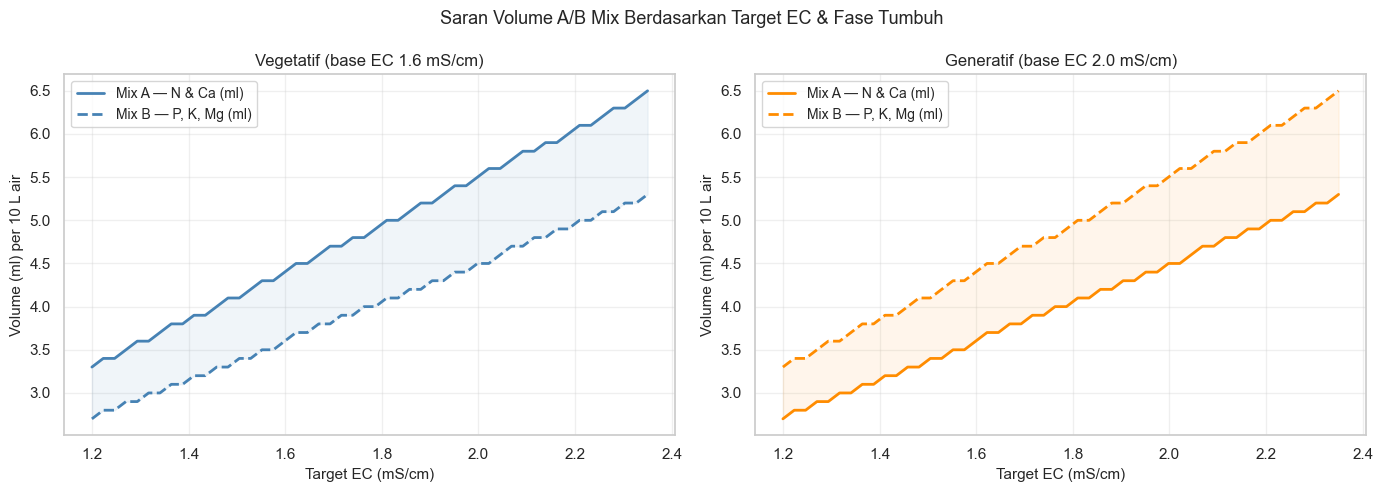

📊 Grafik disimpan -> saran_ab_mix.png


In [9]:
ec_range = np.linspace(1.2, 2.35, 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fase_val, label, col in zip(
        axes, [0, 1],
        ['Vegetatif (base EC 1.6 mS/cm)', 'Generatif (base EC 2.0 mS/cm)'],
        ['steelblue', 'darkorange']):

    vol_a = [saran_ab_mix(ec, fase_val, 1.0)['volume_a_ml'] for ec in ec_range]
    vol_b = [saran_ab_mix(ec, fase_val, 1.0)['volume_b_ml'] for ec in ec_range]

    ax.plot(ec_range, vol_a, label='Mix A — N & Ca (ml)', color=col, linewidth=2)
    ax.plot(ec_range, vol_b, label='Mix B — P, K, Mg (ml)', color=col,
            linewidth=2, linestyle='--')
    ax.fill_between(ec_range, vol_a, vol_b, alpha=0.08, color=col)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Target EC (mS/cm)', fontsize=11)
    ax.set_ylabel('Volume (ml) per 10 L air', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Saran Volume A/B Mix Berdasarkan Target EC & Fase Tumbuh', fontsize=13)
plt.tight_layout()
plt.savefig('saran_ab_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Grafik disimpan -> saran_ab_mix.png')

## Cell 8 — Simpan Model & Metadata

In [ ]:
joblib.dump(rf, 'model1_target_ec.pkl')
print('✅ Model disimpan -> model1_target_ec.pkl')

metadata = {
    'model'    : 'RandomForestRegressor',
    'features' : FEATURES,
    'target'   : TARGET,
    'n_samples': len(df),
    'metrics'  : {
        'mae'       : round(mae, 4),
        'rmse'      : round(rmse, 4),
        'r2'        : round(r2, 4),
        'cv_r2_mean': round(cv.mean(), 4),
        'cv_r2_std' : round(cv.std(), 4),
    },
    'ec_range'           : {'min': 1.2, 'max': 2.35},
    'ec_vegetatif_base'  : 1.6,
    'ec_generatif_base'  : 2.0,
    'ab_mix_note'        : '5 ml A + 5 ml B per 10 L = 1 mS/cm EC',
    'vpd_formula'        : 'es=0.6108*exp(17.27*T/(T+237.3)); vpd=es*(1-RH/100)',
    'input_schema': {
        'n':'ppm','p':'ppm','k':'ppm',
        'ec_aktual':'mS/cm',
        'kelembapan_udara':'%','kelembapan_tanah':'%',
        'suhu':'C','fase':'0=veg/1=gen','usia_hst':'hari'
    }
}
with open('model1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Metadata disimpan -> model1_metadata.json')

print()
print('── Cara load di Flask/FastAPI ──')
print("""
import joblib, json, numpy as np

rf   = joblib.load('model1_target_ec.pkl')
meta = json.load(open('model1_metadata.json'))

# @app.post('/predict')
# def predict(data: SensorData):
#     result = prediksi_full(**data.dict())
#     return result
""")